# Prédiction du score d'addiction à l'alcool
## Modèles de Machine Learning (comparaison et analyse) 

**Dataset :** Students-mat   
**Variable cible :** `Dalc` — Nombre de verres d'alcool par jour

Ce notebook charge les données, fait le preprocessing, puis appelle chaque modèle depuis le dossier `models/`.  
Il compare ensuite les résultats et propose un exemple d'application concret.

In [ ]:
#%pip install scikit-learn
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score)


from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBRegressor

## 2 - Chargement et preprocessing

On charge le dataset, séparons les données de la variable que l'on veut prédire et on convertit les variables textuelles en nombres avec `LabelEncoder` et `oneHotEncoder`.

Ensuite on sépare les données en 80% entraînement / 20% test.

In [ ]:
from models.ACP import ACP
from models.encoder import labelEncoder, oneHotEncoder


df = pd.read_csv("BDD_initial/student-mat.csv", sep=",", index_col=0)

y = df['Dalc']
X_raw = df[["G1", "G2", "G3", "freetime", "goout", "health", "absences", "age", "studytime", "Mjob","Fjob", "reason", "activities","romantic"]]

# LabelEncoder
X_le  = labelEncoder(X_raw.copy())

# OneHotEncoder
X_ohe = oneHotEncoder(X_raw.copy())

# ACP
x_acp = ACP(X_ohe, n_components=20)

# Split — même random_state pour comparer sur les mêmes données
X_train_le,  X_test_le,  y_train_le, y_test_le = train_test_split(X_le,  y, test_size=0.2, random_state=42)
X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe= train_test_split(X_ohe, y, test_size=0.2, random_state=42)

X_train_acp, X_test_acp, y_train_acp, y_test_acp = train_test_split(x_acp, y, test_size=0.2, random_state=42)


# label_encoders conservé pour l'exemple étudiant (cell 16)
from sklearn.preprocessing import LabelEncoder
cat_cols = df.select_dtypes(include='object').columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(df[col])
    label_encoders[col] = le

print('X_le  shape:', X_le.shape)
print('X_ohe shape:', X_ohe.shape)
print('Train / Test:', X_train_le.shape[0], '/', X_test_le.shape[0])


X_le  shape: (395, 14)
X_ohe shape: (395, 27)
Train / Test: 316 / 79


C:\Users\sidsm\AppData\Local\Temp\ipykernel_17276\2964850864.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


## 3. Entraînement des modèles

Chaque modèle est dans un fichier séparé dans `models/`.  
La fonction `run(X_train, X_test, y_train, y_test)` retourne un dictionnaire avec les métriques.

Tous les modèles sont présents en 2 versions : 
la version initial avec GridSearchCV est la meilleur mais peut prendre plusieurs minutes, la version 2 avec RandomizedSearchCV est plus courte mais moins précise. 

> **Pour ajouter un modèle** : importer sa fonction `run` et l'ajouter au dictionnaire `modeles`.

In [6]:

from models.random_forest_rgs_v2 import run as run_rf
from models.xgboost_rgs_v2 import run as run_xgb_rgs
from models.xgboost import run as run_xgb
from models.knn_rgs import run as run_knn
from models.naive_bayes_rgs_v2 import run as run_nb_rgs

modeles = {
    'KNN'          : run_knn,
    'xgboost rgs'  : run_xgb_rgs,
    'Naive Bayes rgs'  : run_nb_rgs,
    'XGBoost'      : run_xgb,
    'Random Forest': run_rf,
}

resultats = {}
for nom, run_fn in modeles.items():
    print(f'Entraînement : {nom}...')
    resultats[f'{nom} (LE)']  = run_fn(X_train_le,  X_test_le,  y_train_le, y_test_le)
    resultats[f'{nom} (OHE)'] = run_fn(X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe)
    resultats[f'{nom} (ACP)'] = run_fn(X_train_acp, X_test_acp, y_train_acp, y_test_acp)

    print(f"  LE  R²: {resultats[f'{nom} (LE)']['optimized']['r2']:.4f}")
    print(f"  OHE R²: {resultats[f'{nom} (OHE)']['optimized']['r2']:.4f}")
    print(f"  ACP R²: {resultats[f'{nom} (ACP)']['optimized']['r2']:.4f}")

print('\nTerminé.')


Entraînement : KNN...
  LE  R²: 0.0913
  OHE R²: 0.0371
  ACP R²: 0.0287
Entraînement : xgboost rgs...
  LE  R²: -0.1020
  OHE R²: -0.1046
  ACP R²: 0.0579
Entraînement : Naive Bayes rgs...
  LE  R²: -0.0861
  OHE R²: -6.7035
  ACP R²: -0.1794
Entraînement : XGBoost...
  LE  R²: -0.1092
  OHE R²: -0.2595
  ACP R²: 0.0003
Entraînement : Random Forest...
  LE  R²: -0.1911
  OHE R²: -0.1322
  ACP R²: -0.0193

Terminé.


In [8]:
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression

# 1. Extraction des vrais modèles (estimateurs Scikit-Learn) 
estimators_acp = [
    ('KNN', resultats['KNN (ACP)']['model']),
    ('xgb_rgs', resultats['xgboost rgs (ACP)']['model']),
    ('xgb', resultats['XGBoost (ACP)']['model']),
    ('rf', resultats['Random Forest (ACP)']['model'])
]

print('\nEntraînement des modèles d\'Ensemble...')

# 2. Voting Regressor (Fait la moyenne des prédictions)
model_voting = VotingRegressor(estimators=estimators_acp)

model_voting.fit(X_train_acp, y_train_acp) 
score_voting_acp = model_voting.score(X_test_acp, y_test_acp)

model_voting.fit(X_train_ohe, y_train_ohe) 
score_voting_ohe = model_voting.score(X_test_ohe, y_test_ohe)

model_voting.fit(X_train_le, y_train_le) 
score_voting_le = model_voting.score(X_test_le, y_test_le)

print(f"  Voting Regressor (ACP) R²: {score_voting_acp:.4f}")
print(f"  Voting Regressor (OHE) R²: {score_voting_ohe:.4f}")
print(f"  Voting Regressor (LE) R²: {score_voting_le:.4f}")

# 3. Stacking Regressor (Utilise un modèle final pour trancher)
model_stack = StackingRegressor(
    estimators=estimators_acp,
    final_estimator=LinearRegression(),
    cv=3 # Ajout de cv=3 pour accélérer l'entraînement interne
)
model_stack.fit(X_train_acp, y_train_acp)
score_stacking_acp = model_stack.score(X_test_acp, y_test_acp)

model_stack.fit(X_train_ohe, y_train_ohe) 
score_stacking_ohe = model_stack.score(X_test_ohe, y_test_ohe)

model_stack.fit(X_train_le, y_train_le) 
score_stacking_le = model_stack.score(X_test_le, y_test_le)

print(f"  Stacking Regressor (ACP) R²: {score_stacking_acp:.4f}")
print(f"  Stacking Regressor (OHE) R²: {score_stacking_ohe:.4f}")
print(f"  Stacking Regressor (LE) R²: {score_stacking_le:.4f}")


print('\nTerminé.')


Entraînement des modèles d'Ensemble...
  Voting Regressor (ACP) R²: 0.0409
  Voting Regressor (OHE) R²: -0.0357
  Voting Regressor (LE) R²: -0.0330
  Stacking Regressor (ACP) R²: 0.0139
  Stacking Regressor (OHE) R²: -0.0692
  Stacking Regressor (LE) R²: -0.0403

Terminé.


### 4 Entrainement d'une plus grande variété de modèles d'apprentissage


In [13]:
clf = DecisionTreeRegressor(random_state=0)
scores = cross_val_score(clf, X_ohe, y, cv=5)
scores.mean()
print("Scores OHE : ", scores)
print(scores.mean())

clf = DecisionTreeRegressor(random_state=0)
scores = cross_val_score(clf, X_le, y, cv=5)
scores.mean()
print("Scores LE : ", scores)
print(scores.mean())

clf = DecisionTreeRegressor(random_state=0)
scores = cross_val_score(clf, x_acp, y, cv=5)
scores.mean()
print("Scores ACP : ", scores)
print(scores.mean())

Scores OHE :  [-0.63122347 -2.18393939 -0.63456752 -2.29374605 -0.6863711 ]
-1.285969505771983
Scores LE :  [-0.28058665 -2.80636364 -1.3719664  -1.09602021 -0.6863711 ]
-1.2482615988811125
Scores ACP :  [-0.64646854 -0.9869697  -0.49937772 -2.64308275 -0.85500821]
-1.1261813857683864


Les modèles de régressions ne sont ici pas performant, particulièrement en comparaison avec les modèles de classifications. 

In [17]:
def nbr_estimator_model(model,n_estim=100):
    best = 0
    best_k=0
    for k in range (1,n_estim,1):
        model_train = model(n_estimators=k)
        model_train.fit(X_train_acp, y_train_acp)
        score = model_train.score(X_test_acp, y_test_acp)
        if(best<score):
            best=score
            best_k=k
    print("best : ",best_k,best)
    return [best_k,best]

In [16]:
modeles = {
    "decision_tree_regressor": DecisionTreeRegressor(),
    "XGBRegressor":XGBRegressor(n_estimators=100,random_state=42),
    "decision_tree_classifier": DecisionTreeClassifier(),
    "random_forest_classifier": RandomForestClassifier(n_estimators=10, max_depth=3),
    "logistic_regression": LogisticRegression(max_iter=1000),
    "gaussian_nb": GaussianNB(),
    "sgd_classifier": SGDClassifier(random_state=1),
    "knn_classifier": KNeighborsClassifier(n_neighbors=5),
    "bagging_classifier": BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10)

}

Best=None
score_Best=-np.inf
list_model_voting = []
for nom, model in modeles.items():
    model.fit(X_train_acp, y_train_acp)
    score_model = model.score(X_test_acp,y_test_acp)
    print(f"{nom} : {score_model:.4f}")
    if score_model >score_Best:
        Best=model
        score_Best=score_model
    if(score_model >0.5):
        list_model_voting.append((nom, model))
        
model_0 = VotingClassifier(list_model_voting,
                          voting='hard')
model_0.fit(X_train_acp, y_train_acp)
model_0.score(X_test_acp, y_test_acp)

model_stack = StackingClassifier(list_model_voting,
                             final_estimator=model_0)
model_stack.fit(X_train_acp, y_train_acp)
model_stack.score(X_test_acp, y_test_acp)

if(score_Best>model_0.score(X_train_acp, y_train_acp)):
    best=model_0
if(score_Best>model_stack.score(X_test_acp, y_test_acp)):
    best=model_stack
print(f"\n\nMeilleur modèle : {best.__class__.__name__} avec un score de {score_Best:.4f}\n\n")

decision_tree_regressor : -0.7261
XGBRegressor : -0.2734
decision_tree_classifier : 0.5443
random_forest_classifier : 0.7595
logistic_regression : 0.7215
gaussian_nb : 0.6329
sgd_classifier : 0.6203
knn_classifier : 0.7468
bagging_classifier : 0.7089


Meilleur modèle : StackingClassifier avec un score de 0.7595




c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 4. Tableau comparatif

On compare les modèles sur trois métriques :
- **R²** : proportion de variance expliquée (plus c'est proche de 1, mieux c'est)
- **MAE** : erreur moyenne en points de score
- **RMSE** : similaire au MAE, mais pénalise plus les grandes erreurs

In [19]:
rows = []
for nom, res in resultats.items():
    opt = res['optimized']
    rows.append({
        'Modèle': nom,
        'R²'    : round(opt['r2'],   4),
        'MAE'   : round(opt['mae'],  4),
        'RMSE'  : round(opt['rmse'], 4),
    })

df_comparaison = pd.DataFrame(rows).sort_values('R²', ascending=False).set_index('Modèle')
df_comparaison

,R²,MAE,RMSE
Modèle,,,
KNN (LE),0.0913,0.5970,0.7956
xgboost rgs (ACP),0.0579,0.6099,0.8102
KNN (OHE),0.0371,0.5990,0.8190
KNN (ACP),0.0287,0.6022,0.8226
XGBoost (ACP),0.0003,0.6227,0.8346
Random Forest (ACP),-0.0193,0.6249,0.8427
Naive Bayes rgs (LE),-0.0861,0.5954,0.8699
xgboost rgs (LE),-0.1020,0.6568,0.8762
xgboost rgs (OHE),-0.1046,0.6455,0.8772


## 5. Visualisation des métriques

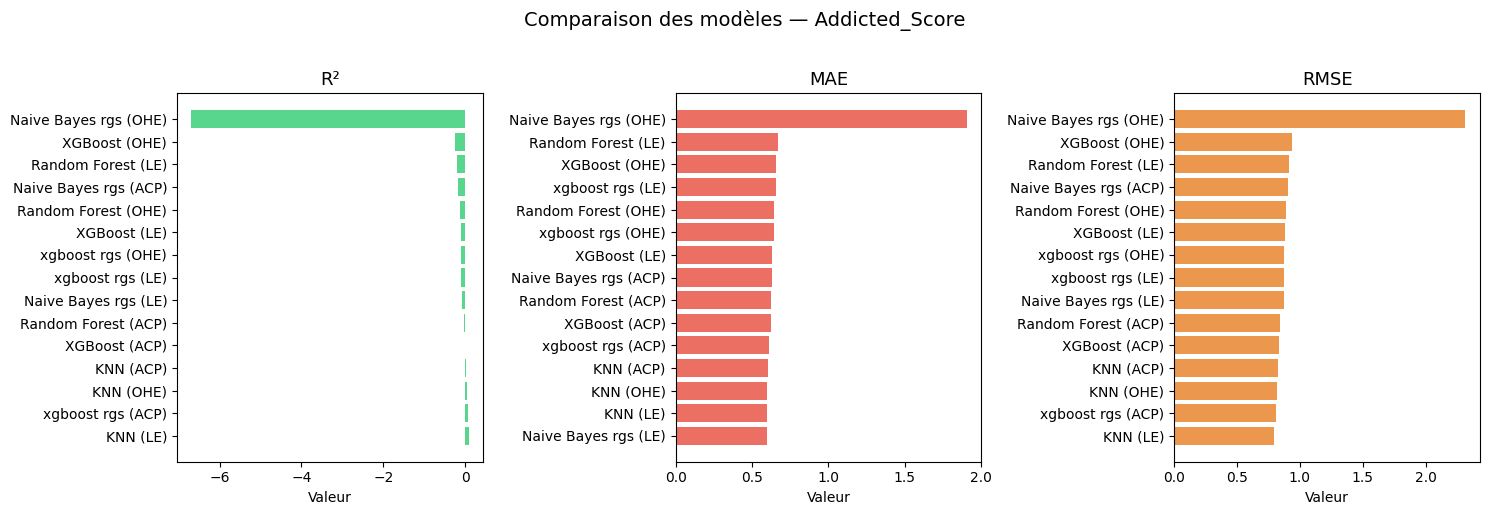

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [('R²', '#2ecc71', False), ('MAE', '#e74c3c', True), ('RMSE', '#e67e22', True)]

for ax, (metric, color, ascending) in zip(axes, metrics):
    vals = df_comparaison[metric].sort_values(ascending=ascending)
    ax.barh(vals.index, vals.values, color=color, alpha=0.8)
    ax.set_title(metric, fontsize=13)
    ax.set_xlabel('Valeur')

plt.suptitle('Comparaison des modèles — Addicted_Score', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Exemple d'application

On crée un profil d'étudiant fictif et on demande au modèle de prédire son score d'addiction.  
Les variables catégorielles sont encodées avec les mêmes `LabelEncoder` utilisés à l'étape 2.

In [21]:

# exemple d'un étudiant fictif
# Profil d'un étudiant "type" (médian) du jeu de données
etudiant = {
    'G1'         : 11,        # Note du 1er trimestre (sur 20)
    'G2'         : 11,        # Note du 2ème trimestre (sur 20)
    'G3'         : 11,        # Note finale (sur 20)
    'freetime'   : 3,         # Temps libre après l'école (1: très faible à 5: très élevé)
    'goout'      : 3,         # Fréquence de sortie avec des amis (1 à 5)
    'health'     : 4,         # État de santé actuel (1: très mauvais à 5: très bon)
    'absences'   : 4,         # Nombre d'absences scolaires
    'age'        : 17,        # Âge de l'étudiant
    'studytime'  : 2,         # Temps d'étude hebdomadaire (2 = 2 à 5 heures)
    'Mjob'       : 'other',   # Métier de la mère (catégorie la plus fréquente)
    'Fjob'       : 'other',   # Métier du père
    'reason'     : 'course',  # Raison du choix de l'école (préférence pour les cours)
    'activities' : 'yes',     # Participation à des activités extrascolaires
    'romantic'   : 'no',      # Dans une relation amoureuse ?
}

# trouve le meilleur modèle selon R²
meilleur_cle = max(resultats, key=lambda k: resultats[k]['optimized']['r2'])
meilleur_r2  = resultats[meilleur_cle]['optimized']['r2']

etudiant_df = pd.DataFrame([etudiant])

# encodage
etudiant_enc = {}
for col, val in etudiant.items():
    if col in label_encoders:
        etudiant_enc[col] = label_encoders[col].transform([val])[0]
    else:
        etudiant_enc[col] = val

if '(LE)' in meilleur_cle:
    X_etudiant = pd.DataFrame([etudiant_enc])[X_le.columns]
else:
    etudiant_ohe_raw = oneHotEncoder(etudiant_df.copy())
    X_etudiant       = etudiant_ohe_raw.reindex(columns=X_ohe.columns, fill_value=0)

score_predit = resultats[meilleur_cle]['model'].predict(X_etudiant)[0]

print("=== Profil de l'étudiant ===")
for k, v in etudiant.items():
    print(f"  {k:<35} : {v}")

print(f"\n Modèle utilisé : {meilleur_cle}  (R² = {meilleur_r2:.4f})")
print(f" Score prédit   : {score_predit:.2f} / 9")

if score_predit >= 7:
    print("    → Niveau élevé d'addiction")
elif score_predit >= 4:
    print("    → Niveau modéré d'addiction")
else:
    print("    → Niveau faible d'addiction")

=== Profil de l'étudiant ===
  G1                                  : 11
  G2                                  : 11
  G3                                  : 11
  freetime                            : 3
  goout                               : 3
  health                              : 4
  absences                            : 4
  age                                 : 17
  studytime                           : 2
  Mjob                                : other
  Fjob                                : other
  reason                              : course
  activities                          : yes
  romantic                            : no

 Modèle utilisé : KNN (LE)  (R² = 0.0913)
 Score prédit   : 1.45 / 9
    → Niveau faible d'addiction


In [ ]:
# On crée un faux profil d'étudiant pour tester
# Note : Il doit avoir exactement les mêmes colonnes que data_mat_final (après OneHot)
nouveau_profil = X_test[0:1] # On prend le premier étudiant du test pour l'exemple

# --- TYPE 1 : Prédiction de Classe (Classification) ---
classe_predite = model.predict(nouveau_profil)
probabilites = model.predict_proba(nouveau_profil) # Probabilité pour chaque niveau (1 à 5)

print(f"Classe prédite (Niveau de consommation) : {classe_predite[0]}")
print(f"Confiance du modèle : {np.max(probabilites)*100:.2f}%")

# --- TYPE 2 : Prédiction de Score Continu (Si on utilisait un Régresseur) ---
# Si vous aviez utilisé XGBRegressor ou RandomForestRegressor :
# score_continu = model_regresseur.predict(nouveau_profil)

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_final_pred = model.predict(y_test_acp)

conf_matrix = confusion_matrix(y_test_acp, y_final_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.ylabel('Réalité (Vrai score Dalc)')
plt.xlabel('Prédiction (Score prédit)')
plt.title('Matrice de Confusion : Où le modèle se trompe-t-il ?')
plt.show()

print(classification_report(y_test_acp, y_final_pred))

ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

Cette matrice confirme les analyses que nous avons déjà effectuées dans le notebook de prévisualisation des données : notre jeu de donnée contient une grande majorité de valeur 1 pour la variable Dalc, ce qui fait que notre modèle atteint un score d'accuracy de 0.80 uniquement en prédisant 1. 